# Sand Production Risk Classification with Imbalanced Learning

**Goal:** rank wells by sanding risk with a 7%-positive dataset, and set the alarm
threshold from an operations recall requirement, not a default 0.5.

**Technique highlights**
* Why accuracy and ROC-AUC mislead at 7% positives — PR curve instead
* Class weighting vs naive fit, compared on the same folds
* Threshold chosen for **90% recall** (missing a sander is the expensive error)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic well population

In [2]:
N = 5_000
ucs_psi = rng.lognormal(8.3, 0.5, N)                     # ~2,000-15,000 psi
drawdown_psi = rng.uniform(100, 2_200, N)
depletion_psi = np.abs(rng.normal(500, 450, N))
wct = np.clip(rng.beta(1.5, 4, N), 0, 1)
gravel_pack = (rng.random(N) < 0.25).astype(int)
perf_density = rng.uniform(4, 16, N)                     # spf

failure_stress = 1.7 * drawdown_psi + 0.9 * depletion_psi
risk = (
    2.2 * np.maximum(failure_stress / ucs_psi - 0.25, 0)
    + 1.4 * wct
    - 1.8 * gravel_pack
    + 0.02 * (16 - perf_density)
    + rng.normal(0, 0.35, N)
)
sanded = (risk > np.quantile(risk, 0.93)).astype(int)

df = pd.DataFrame({
    "ucs_psi": ucs_psi.round(0), "drawdown_psi": drawdown_psi.round(0),
    "depletion_psi": depletion_psi.round(0), "wct": wct.round(2),
    "gravel_pack": gravel_pack, "perf_density_spf": perf_density.round(1),
    "sanded": sanded,
})
df.to_csv("sanding_well_data.csv", index=False)
print(f"Positive rate: {sanded.mean():.1%}")

Positive rate: 7.0%


## 2. Naive vs class-weighted models

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix)

FEATURES = df.columns[:-1].tolist()
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df.sanded, test_size=0.3,
                                          stratify=df.sanded, random_state=42)

models = {
    "naive": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "class-weighted": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             min_samples_leaf=4, random_state=42, n_jobs=-1),
}
probas = {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:, 1]
    probas[name] = p
    acc = (m.predict(X_te) == y_te).mean()
    print(f"{name:15s} accuracy={acc:.3f}  ROC-AUC={roc_auc_score(y_te, p):.3f}  "
          f"PR-AUC={average_precision_score(y_te, p):.3f}  "
          f"default-threshold recall={confusion_matrix(y_te, m.predict(X_te))[1,1] / y_te.sum():.2f}")

naive           accuracy=0.979  ROC-AUC=0.991  PR-AUC=0.930  default-threshold recall=0.73


class-weighted  accuracy=0.965  ROC-AUC=0.990  PR-AUC=0.908  default-threshold recall=0.90


Both models post ~high accuracy and similar ROC-AUC — but the default-threshold
recall shows the naive model quietly misses sanders. PR space tells the real story.

## 3. Precision-recall analysis and threshold at 90% recall

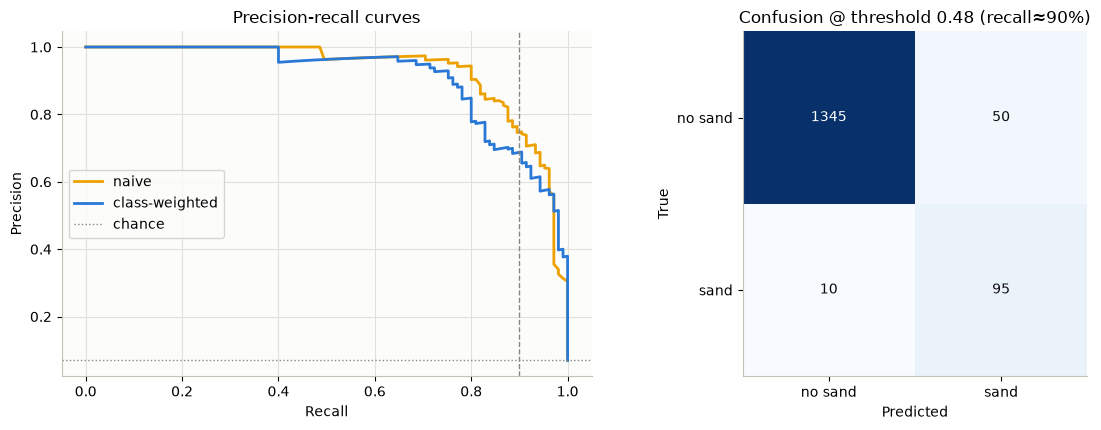

At 90% recall: precision = 0.66 → screen-candidate list is 9.7% of wells


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for name, color in [("naive", PALETTE[2]), ("class-weighted", PALETTE[0])]:
    prec, rec, thr = precision_recall_curve(y_te, probas[name])
    axes[0].plot(rec, prec, lw=2, color=color, label=name)
axes[0].axhline(y_te.mean(), ls=":", lw=1, color="#898781", label="chance")
axes[0].axvline(0.9, ls="--", lw=1, color="#898781")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves")
axes[0].legend()

prec, rec, thr = precision_recall_curve(y_te, probas["class-weighted"])
i90 = np.argmin(np.abs(rec[:-1] - 0.9))
thr90 = thr[i90]
pred90 = (probas["class-weighted"] >= thr90).astype(int)
cm = confusion_matrix(y_te, pred90)
axes[1].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "#0b0b0b")
axes[1].set_xticks([0, 1], ["no sand", "sand"])
axes[1].set_yticks([0, 1], ["no sand", "sand"])
axes[1].set(xlabel="Predicted", ylabel="True",
            title=f"Confusion @ threshold {thr90:.2f} (recall≈90%)")
axes[1].grid(False)
plt.tight_layout()
plt.show()
print(f"At 90% recall: precision = {prec[i90]:.2f} → screen-candidate list is "
      f"{pred90.mean():.1%} of wells")

## 4. What drives risk — and the screening economics

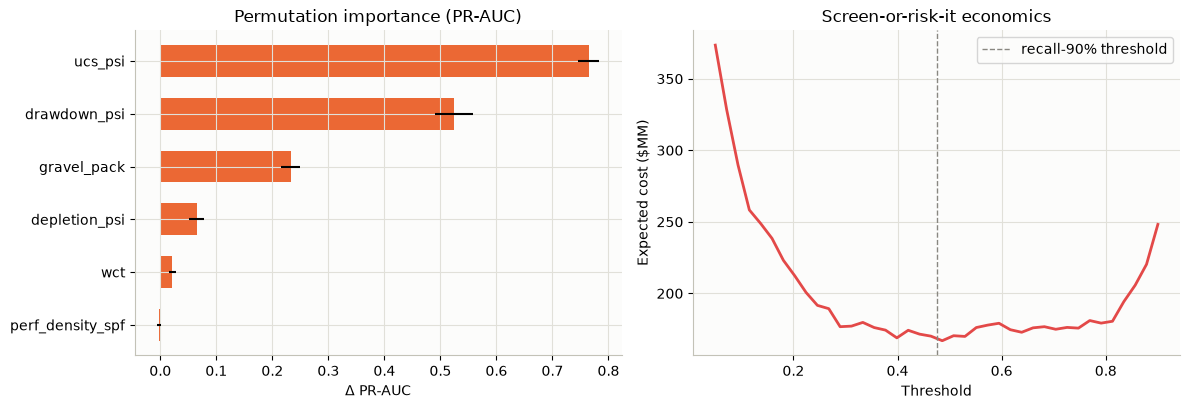

In [5]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(models["class-weighted"], X_te, y_te,
                             n_repeats=15, random_state=42,
                             scoring="average_precision")
order = np.argsort(imp.importances_mean)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].barh([FEATURES[i] for i in order], imp.importances_mean[order],
             xerr=imp.importances_std[order], color=PALETTE[7], height=0.6)
axes[0].set(title="Permutation importance (PR-AUC)", xlabel="Δ PR-AUC")

COST_SANDER, COST_SCREEN = 4_000_000, 900_000
threshold_sweep = np.linspace(0.05, 0.9, 40)
costs = []
for t in threshold_sweep:
    pred = probas["class-weighted"] >= t
    fn = ((~pred) & (y_te == 1)).sum()
    tp_fp = pred.sum()
    costs.append((fn * COST_SANDER + tp_fp * COST_SCREEN) / 1e6)
axes[1].plot(threshold_sweep, costs, lw=2, color=PALETTE[5])
axes[1].axvline(thr90, ls="--", lw=1, color="#898781", label="recall-90% threshold")
axes[1].set(xlabel="Threshold", ylabel="Expected cost ($MM)",
            title="Screen-or-risk-it economics")
axes[1].legend()
plt.tight_layout()
plt.show()

## Conclusions

* Accuracy (~95%) and ROC-AUC hid the difference between models; the **PR curve and
  default-threshold recall exposed it** — the core lesson of imbalanced learning.
* At the operations-driven 90% recall point, the screen-candidate list is small enough
  to be actionable, and the cost curve shows the recall-90 threshold sits near the
  economic optimum given the 4:1 miss-to-screen cost ratio.
* Drivers rank as the physics says they should: strength-normalized stress, water cut,
  completion type.
* **Next step:** survival analysis (time-to-sanding) instead of binary outcome, and
  coupling with erosion-rate models for produced-sand tolerance decisions.